In [1]:
import os
import sys
from captcha.image import ImageCaptcha
from PIL import Image
from torchvision import transforms
import torch
import string
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import io
import random
from pathlib import Path
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F_nn
import torchvision.transforms.functional as F_cv

sys.path.append(os.path.abspath(os.path.join("../..")))
from src.models.crnn.crnn_v1 import Captcha_CRNN_V1
from src.models.convoluationaltransformer.convtrans_v1 import Captcha_Convolutional_Transformer_V1

# Load Data & Model

In [2]:
captcha_transformation = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((40, 150)),
        transforms.ToTensor(),
    ]
)

In [ ]:
# vocab = string.ascii_lowercase + string.ascii_uppercase + string.digits
# idx_to_char = {i + 1: c for i, c in enumerate(vocab)}
# idx_to_char[0] = ""

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = Captcha_CRNN_V1(num_chars=len(vocab) + 1)
# state_dict = torch.load(Captcha_CRNN_V1.SAVE_DIR / "v5.pth", map_location=device)
# model.load_state_dict(state_dict)
# model.to(device)
# model.eval() 

# # print(f"Model successfully loaded from {Captcha_CRNN_V1.SAVE_DIR / "v3.pth"}")
# print(f"Model successfully loaded from {Captcha_CRNN_V1.SAVE_DIR / "v5.pth"}")

Model successfully loaded from /nfs/home/tpz8688/Captcha-Recognition/weights/crnn/v5.pth


In [3]:
vocab = string.ascii_lowercase + string.ascii_uppercase + string.digits
idx_to_char = {i + 1: c for i, c in enumerate(vocab)}
idx_to_char[0] = ""

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Captcha_Convolutional_Transformer_V1(num_chars=len(vocab) + 1)
state_dict = torch.load(Captcha_Convolutional_Transformer_V1.SAVE_DIR / "v6.pth", map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval() 

print(f"Model successfully loaded from {Captcha_Convolutional_Transformer_V1.SAVE_DIR / "v6.pth"}")

/nfs/home/tpz8688/Captcha-Recognition/src/models/convoluationaltransformer/convtrans_v1.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Model successfully loaded from /nfs/home/tpz8688/Captcha-Recognition/weights/conv_transformer/v6.pth


# Helper Functions

In [4]:
def decode_predictions(logits):
    tokens = torch.argmax(logits, dim=-1)

    char_list = []
    for i in range(len(tokens)):
        token = tokens[i].item()
        if token != 0:
            if i > 0 and tokens[i] == tokens[i - 1]:
                continue
            char_list.append(idx_to_char[token])

    return "".join(char_list)

In [5]:
def generate_image(input_str):
    generator = ImageCaptcha(fonts=["/nfs/home/tpz8688/Captcha-Recognition/data/Nunito.ttf"])

    # Config
    # generator.character_offset_dx: (0, 0)
    # generator.character_offset_dy: (100, 200)
    # generator.character_rotate = (-0, 0)
    # generator.character_wrap_dx = (-0, 0)
    # generator.character_wrap_dy = (-0, 0)
    # generator.word_space_probability = 0
    # generator.word_offset_dx = 0.0

    image_data = generator.generate(input_str)
    return Image.open(image_data)

In [6]:
def test_live_captcha(input_str, model, device, transform, rotation=0, alpha=0):
    """
    input_str: The text to generate
    rotation: Degrees to rotate
    alpha: Elastic distortion intensity
    """
    # 1. Generate the raw colored image
    raw_image = generate_image(input_str) # Assuming this returns a PIL Image
    
    # 2. Apply distortions to the RAW (colored) image
    # Note: We use fill=255 here because we are still in 0-255 PIL space
    distorted_raw = raw_image
    
    if alpha > 0:
        elasticter = v2.ElasticTransform(alpha=float(alpha), sigma=9.0, fill=255)
        distorted_raw = elasticter(distorted_raw)
    
    if rotation != 0:
        distorted_raw = F_nn.rotate(distorted_raw, angle=float(rotation), fill=255)
    
    # 3. Prepare for Model (Grayscale, Resize, ToTensor)
    # This matches the 'cpu_transform' we discussed earlier
    input_tensor = transform(distorted_raw).unsqueeze(0).to(device)
    
    # 4. Model Inference
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        prediction = decode_predictions(logits.squeeze(0))
    
    # 5. Visualization
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Original Clean Image
    plt.subplot(1, 2, 1)
    plt.imshow(distorted_raw)
    plt.title(f"Original: '{input_str}'")
    plt.axis('off')
    
    # Plot 3: Result
    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.6, f"Model Prediction:", fontsize=14, ha='center')
    color = 'green' if prediction == input_str else 'red'
    plt.text(0.5, 0.4, f"{prediction}", fontsize=24, fontweight='bold', ha='center', color=color)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

In [7]:
def test_live_captcha_with_grid(input_str, model, device, transform, rotation=0, alpha=0):
    # 1. Generate the raw colored image
    raw_image = generate_image(input_str) 
    
    # 2. Apply distortions
    distorted_raw = raw_image
    
    if alpha > 0:
        # v2.ElasticTransform is an object, so we call it on the image
        elasticter = v2.ElasticTransform(alpha=float(alpha), sigma=9.0, fill=255)
        distorted_raw = elasticter(distorted_raw)
    
    if rotation != 0:
        # FIX: Use F_cv (torchvision) for image manipulation
        distorted_raw = F_cv.rotate(distorted_raw, angle=float(rotation), fill=255)
    
    # 3. Prepare for Model
    input_tensor = transform(distorted_raw).unsqueeze(0).to(device)
    
    # 4. Model Inference
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor) # Shape: [1, seq_len, num_classes]
        
        # FIX: Use F_nn (torch.nn.functional) for Softmax math
        probs = F_nn.softmax(logits, dim=-1).squeeze(0) 
        
        # In CRNNs, we take the max probability at each time step
        confidences, pred_indices = torch.max(probs, dim=1)
        prediction = decode_predictions(logits.squeeze(0))
        
    # 5. Visualization Grid
    # Use the length of the prediction to avoid index errors
    display_len = len(prediction) if len(prediction) > 0 else len(input_str)
    fig = plt.figure(figsize=(display_len * 1.5, 5))
    
    ax_img = plt.subplot2grid((3, display_len), (0, 0), colspan=display_len)
    ax_img.imshow(distorted_raw)
    ax_img.set_title(f"Target: {input_str} | Pred: {prediction}")
    ax_img.axis('off')

    for i in range(display_len):
        # Determine if correct
        char_pred = prediction[i] if i < len(prediction) else ""
        char_true = input_str[i] if i < len(input_str) else ""
        
        is_correct = (char_pred == char_true)
        base_color = 'green' if is_correct else 'red'
        
        # Simple heuristic: map the sequence confidence to the character
        # (CRNN outputs are longer than the string, so we sample the sequence)
        idx = int(i * (len(confidences) / display_len))
        conf = confidences[idx].item()
        
        ax_char = plt.subplot2grid((3, display_len), (1, i))
        ax_char.text(0.5, 0.5, char_pred, fontsize=20, ha='center', va='center', fontweight='bold')
        ax_char.axis('off')
        
        ax_box = plt.subplot2grid((3, display_len), (2, i))
        rect = plt.Rectangle((0.1, 0.1), 0.8, 0.8, color=base_color, alpha=max(0.1, conf))
        ax_box.add_patch(rect)
        ax_box.set_xticks([]); ax_box.set_yticks([])
        ax_box.set_xlabel(f"{conf:.1%}", fontsize=9)

    plt.tight_layout()
    plt.show()

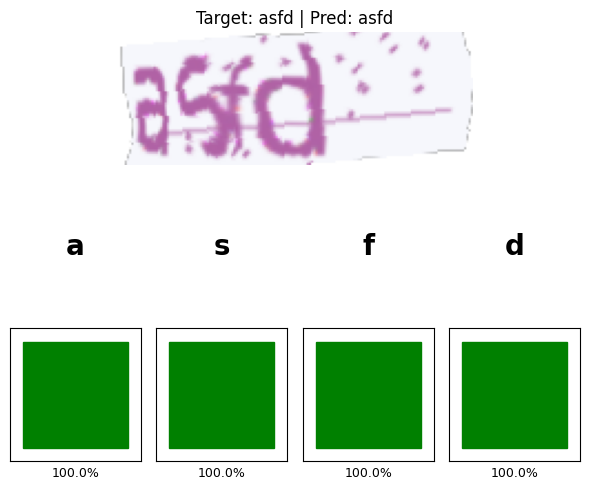

In [33]:
# test_live_captcha("Arielle", model, device, captcha_transformation, rotation=10, alpha=50.0)
test_live_captcha_with_grid("asfd", model, device, captcha_transformation, rotation=5, alpha=100.0)